# Лабораторная №4. Поиск ассоциативных правил в транзакционных данных

Задание №1. Реализация Apriori

In [ ]:
from itertools import combinations
from collections import defaultdict



def apriori_gen(prev_frequent, k):
    """
    Генерация кандидатов размера k из частых наборов размера k-1.
    prev_frequent: list of sorted tuples
    """
    candidates = set()
    n = len(prev_frequent)
    for i in range(n):
        for j in range(i + 1, n):
            l1, l2 = prev_frequent[i], prev_frequent[j]

            if l1[:-1] == l2[:-1]: # Условие слияния. Первые k-2 элемента должны совпадать
                cand = tuple(sorted(set(l1) | set(l2)))
                if len(cand) == k:
                    candidates.add(cand)

    # Шаг отсечения (pruning): убираем кандидатов, чьи подмножества (k-1) не частые
    freq_set = set(prev_frequent)
    pruned = []
    for cand in candidates:
        is_valid = True
        # отсортированные подпоследовательности
        for sub in combinations(cand, k - 1):
            if sub not in freq_set:
                is_valid = False
                break
        if is_valid:
            pruned.append(cand)
    return pruned


def apriori(transactions, min_support):
    """
    Основной цикл алгоритма Apriori.
    Возвращает: dict {sorted_tuple: support_value}
    """
    if not transactions:
        return {}

    trans_sets = [frozenset(t) for t in transactions]
    total = len(trans_sets)

    # 1. Частые 1-элементные наборы
    item_counts = defaultdict(int)
    for t in trans_sets:
        for item in t:
            item_counts[item] += 1

    freq_itemsets = {}
    Lk = []
    for item, cnt in item_counts.items():
        sup = cnt / total
        if sup >= min_support:
            key = (item,)
            freq_itemsets[key] = sup
            Lk.append(key)

    # 2. Итеративный поиск наборов размера k >= 2
    k = 2
    while Lk:
        candidates = apriori_gen(Lk, k)
        if not candidates:
            break

        cand_counts = defaultdict(int)

        for t in trans_sets:
            for cand in candidates:
                if frozenset(cand).issubset(t):
                    cand_counts[cand] += 1

        Lk = []
        for cand, cnt in cand_counts.items():
            sup = cnt / total
            if sup >= min_support:
                freq_itemsets[cand] = sup
                Lk.append(cand)
        k += 1

    return freq_itemsets


def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):
    """
    Генерация ассоциативных правил X -> Y.
    Возвращает: list of tuples (X, Y, support, confidence, lift, conviction, leverage)
    """
    rules = []

    for itemset, sup_itemset in frequent_itemsets.items():
        if len(itemset) < 2:
            continue


        for i in range(1, len(itemset)):
            for X in combinations(itemset, i):
                X = tuple(sorted(X))

                Y = tuple(item for item in itemset if item not in X)

                # 3. Фильтрация по максимальной длине частей правила
                if max_antecedent_len is not None and len(X) > max_antecedent_len:
                    continue
                if max_consequent_len is not None and len(Y) > max_consequent_len:
                    continue

                sup_X = frequent_itemsets.get(X)
                if sup_X is None or sup_X == 0:
                    continue

                confidence = sup_itemset / sup_X
                if confidence < min_confidence:
                    continue

                sup_Y = frequent_itemsets.get(Y, 0.0)


                lift = (confidence / sup_Y) if sup_Y > 0 else 0.0
                if lift < min_lift:
                    continue


                conviction = (1 - sup_Y) / (1 - confidence) if confidence < 1 else float('inf')


                leverage = sup_itemset - (sup_X * sup_Y)

                rules.append((X, Y, sup_itemset, confidence, lift, conviction, leverage))

    return rules

print("Блок 1 (Apriori) успешно загружен.")




Блок 1 (Apriori) успешно загружен.


Задание №2. Реализация FP-Growth

In [ ]:
import math
from collections import defaultdict


class FPNode:
    """Узел FP-дерева."""
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

def _build_tree(trans_paths, min_support_abs, total_trans=None):
    """
    Универсальный построитель дерева (для исходных транзакций и условных баз).
    trans_paths: список транзакций (строк) или список (path, count)
    total_trans: общее число транзакций (нужно только для первого вызова)
    """
    item_counts = defaultdict(int)
    for x in trans_paths:
        path = x[0] if isinstance(x, tuple) else x
        count = x[1] if isinstance(x, tuple) else 1
        for item in path:
            item_counts[item] += count

    # Фильтрация по min_support
    freq_items = {item: cnt for item, cnt in item_counts.items() if cnt >= min_support_abs}
    if not freq_items:
        return None, {}

    # Сортировка: по убыванию частоты, при равенстве  по алфавиту
    sorted_items = sorted(freq_items.items(), key=lambda x: (-x[1], x[0]))
    item_order = {item: i for i, (item, _) in enumerate(sorted_items)}

    root = FPNode(None, 0, None)

    header_table = {item: [sup, None, None] for item, sup in sorted_items}

    for x in trans_paths:
        path = x[0] if isinstance(x, tuple) else x
        count = x[1] if isinstance(x, tuple) else 1

        filtered = [item for item in path if item in freq_items]
        if not filtered:
            continue
        filtered.sort(key=lambda item: item_order[item])

        current = root
        for item in filtered:
            if item in current.children:
                current.children[item].count += count
            else:
                new_node = FPNode(item, count, current)
                current.children[item] = new_node

                # Обновляем горизонтальные ссылки за O(1)
                if header_table[item][1] is None:
                    header_table[item][1] = new_node
                else:
                    header_table[item][2].node_link = new_node
                header_table[item][2] = new_node
            current = current.children[item]

    return root, header_table

def mine_patterns(header_table, min_support_abs, prefix, freq_itemsets, total_trans):
    """Рекурсивный рост частых паттернов."""
    # Перебираем элементы в порядке возрастания поддержки
    items = sorted(header_table.keys(), key=lambda x: header_table[x][0])

    for item in items:
        sup = header_table[item][0]
        if sup < min_support_abs:
            continue

        new_prefix = prefix + [item]
        key = tuple(sorted(new_prefix))
        freq_itemsets[key] = sup / total_trans

        # Формируем условную базу паттернов
        cond_patterns = []
        node = header_table[item][1]
        while node is not None:
            path = []
            parent = node.parent
            while parent.item is not None:
                path.append(parent.item)
                parent = parent.parent
            if path:
                cond_patterns.append((path, node.count))
            node = node.node_link

        # Рекурсивный вызов для условного дерева
        if cond_patterns:
            _, cond_header = _build_tree(cond_patterns, min_support_abs)
            if cond_header:
                mine_patterns(cond_header, min_support_abs, new_prefix, freq_itemsets, total_trans)

def fpgrowth(transactions, min_support):
    """
    Основной алгоритм FP-Growth.
    Возвращает: dict {sorted_tuple: support_value}
    """
    if not transactions:
        return {}

    total = len(transactions)

    abs_min = max(1, math.ceil(min_support * total))

    root, header_table = _build_tree(transactions, abs_min)
    if not header_table:
        return {}

    freq_itemsets = {}
    # Инициализация 1-элементных наборов
    for item, (sup, _, _) in header_table.items():
        if sup >= abs_min:
            freq_itemsets[(item,)] = sup / total


    mine_patterns(header_table, abs_min, [], freq_itemsets, total)
    return freq_itemsets

def generate_rules_fp(frequent_itemsets, min_confidence, min_lift=1.0,
                      max_antecedent_len=None, max_consequent_len=None):
    """
    Генерация ассоциативных правил из частых наборов (обёртка для Блока 1).
    Полностью совместима с форматом {itemset_tuple: support}.
    """

    from Блок_1_имя_файла import generate_rules as _gen_rules
    return _gen_rules(frequent_itemsets, min_confidence, min_lift,
                      max_antecedent_len, max_consequent_len)

print(" Блок 2 (FP‑Growth) успешно загружен.")



 Блок 2 (FP‑Growth) успешно загружен.


Задание №3. Выбор и загрузка реального датасета

In [ ]:

import pandas as pd
import numpy as np
from itertools import chain
from collections import defaultdict


df = pd.read_csv('Assignment-1_Data.csv', sep=';', encoding='utf-8-sig',
                 dtype={'CustomerID': str})
df.dropna(subset=['Itemname'], inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['BillNo'].astype(str).str.match(r'^\d')]


transactions_list = df.groupby('BillNo')['Itemname'].apply(lambda x: list(x.unique())).tolist()
transactions_set = [set(t) for t in transactions_list]


n_trans = len(transactions_list)
unique_items = set(chain.from_iterable(transactions_list))
n_items = len(unique_items)
avg_len = np.mean([len(t) for t in transactions_list])
item_counts = defaultdict(int)
for t in transactions_list:
    for it in t:
        item_counts[it] += 1
top10 = sorted(item_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("===== Статистика датасета =====")
print(f"Транзакций: {n_trans}")
print(f"Уникальных товаров: {n_items}")
print(f"Средняя длина транзакции: {avg_len:.2f}")
print("Топ-10 товаров:")
for item, cnt in top10:
    print(f"  {item}: {cnt} (support: {cnt/n_trans:.4f})")

/tmp/ipykernel_14126/2196357201.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Assignment-1_Data.csv', sep=';', encoding='utf-8-sig',


===== Статистика датасета =====
Транзакций: 19734
Уникальных товаров: 4055
Средняя длина транзакции: 25.81
Топ-10 товаров:
  WHITE HANGING HEART T-LIGHT HOLDER: 2202 (support: 0.1116)
  JUMBO BAG RED RETROSPOT: 2064 (support: 0.1046)
  REGENCY CAKESTAND 3 TIER: 1904 (support: 0.0965)
  PARTY BUNTING: 1656 (support: 0.0839)
  LUNCH BAG RED RETROSPOT: 1541 (support: 0.0781)
  ASSORTED COLOUR BIRD ORNAMENT: 1431 (support: 0.0725)
  SET OF 3 CAKE TINS PANTRY DESIGN: 1346 (support: 0.0682)
  PACK OF 72 RETROSPOT CAKE CASES: 1279 (support: 0.0648)
  LUNCH BAG  BLACK SKULL.: 1260 (support: 0.0638)
  NATURAL SLATE HEART CHALKBOARD: 1232 (support: 0.0624)


Задание №4. Эксперименты с параметрами и поиск правил


min_support = 0.005
  conf=0.5: частых наборов 17918, правил 18210 (0.1 с)
  conf=0.7: частых наборов 17918, правил 8102 (0.1 с)
  conf=0.9: частых наборов 17918, правил 1372 (0.1 с)

min_support = 0.01
  conf=0.5: частых наборов 1896, правил 806 (0.0 с)
  conf=0.7: частых наборов 1896, правил 258 (0.0 с)
  conf=0.9: частых наборов 1896, правил 18 (0.0 с)

min_support = 0.02
  conf=0.5: частых наборов 378, правил 56 (0.0 с)
  conf=0.7: частых наборов 378, правил 10 (0.0 с)
  conf=0.9: частых наборов 378, правил 1 (0.0 с)

min_support = 0.05
  conf=0.5: частых наборов 32, правил 0 (0.0 с)
  conf=0.7: частых наборов 32, правил 0 (0.0 с)
  conf=0.9: частых наборов 32, правил 0 (0.0 с)


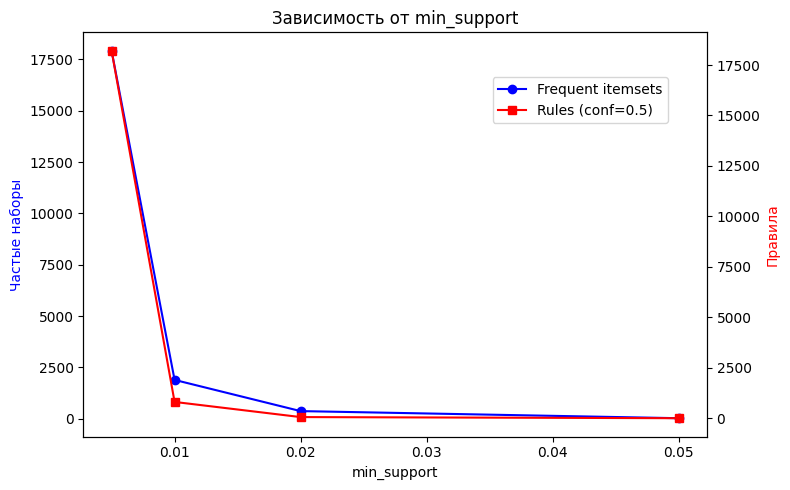


Топ-10 правил по лифту (support=0.005, conf=0.5):
1. ('CHRISTMAS TREE HEART DECORATION', 'CHRISTMAS TREE STAR DECORATION') -> ('CHRISTMAS TREE DECORATION WITH BELL',)
   support=0.0050, confidence=0.7071, lift=111.64
2. ('CHRISTMAS TREE DECORATION WITH BELL', 'CHRISTMAS TREE STAR DECORATION') -> ('CHRISTMAS TREE HEART DECORATION',)
   support=0.0050, confidence=0.9519, lift=104.36
3. ('DOLLY GIRL CHILDRENS CUP', 'SPACEBOY CHILDRENS BOWL', 'SPACEBOY CHILDRENS CUP') -> ('DOLLY GIRL CHILDRENS BOWL',)
   support=0.0051, confidence=0.9806, lift=103.48
4. ('DOLLY GIRL CHILDRENS CUP', 'SPACEBOY CHILDRENS BOWL') -> ('DOLLY GIRL CHILDRENS BOWL',)
   support=0.0057, confidence=0.9576, lift=101.06
5. ('DOLLY GIRL CHILDRENS BOWL', 'SPACEBOY CHILDRENS BOWL', 'SPACEBOY CHILDRENS CUP') -> ('DOLLY GIRL CHILDRENS CUP',)
   support=0.0051, confidence=0.9528, lift=98.96
6. ('DOLLY GIRL CHILDRENS BOWL', 'SPACEBOY CHILDRENS CUP') -> ('DOLLY GIRL CHILDRENS CUP',)
   support=0.0055, confidence=0.9397, lift=

In [ ]:

import time
import matplotlib.pyplot as plt


support_levels = [0.005, 0.01, 0.02, 0.05]
confidence_levels = [0.5, 0.7, 0.9]

results = []

for sup in support_levels:
    print(f"\nmin_support = {sup}")

    freq = fpgrowth(transactions_list, sup)
    for conf in confidence_levels:
        t0 = time.time()
        rules = generate_rules(freq, min_confidence=conf, min_lift=1.0,
                               max_antecedent_len=3, max_consequent_len=1)
        elapsed = time.time() - t0
        print(f"  conf={conf}: частых наборов {len(freq)}, правил {len(rules)} ({elapsed:.1f} с)")
        results.append({
            'support': sup,
            'confidence': conf,
            'n_itemsets': len(freq),
            'n_rules': len(rules),
            'rules': rules
        })

# График зависимости (conf=0.5)
xy_itemsets = [r['n_itemsets'] for r in results if r['confidence'] == 0.5]
xy_rules    = [r['n_rules'] for r in results if r['confidence'] == 0.5]

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.set_xlabel('min_support')
ax1.set_ylabel('Частые наборы', color='blue')
ax1.plot(support_levels, xy_itemsets, marker='o', color='blue', label='Frequent itemsets')
ax2 = ax1.twinx()
ax2.set_ylabel('Правила', color='red')
ax2.plot(support_levels, xy_rules, marker='s', color='red', label='Rules (conf=0.5)')
fig.legend(loc="upper right", bbox_to_anchor=(0.85,0.85))
plt.title('Зависимость от min_support')
plt.tight_layout()
plt.show()


print("\nТоп-10 правил по лифту (support=0.005, conf=0.5):")
sample = [r for r in results if r['support'] == 0.005 and r['confidence'] == 0.5]
if sample:
    top10 = sorted(sample[0]['rules'], key=lambda x: x[4], reverse=True)[:10]
    for i, (X, Y, supp, conf, lift, conv, lev) in enumerate(top10, 1):
        print(f"{i}. {X} -> {Y}")
        print(f"   support={supp:.4f}, confidence={conf:.4f}, lift={lift:.2f}")

Задание №5. Сравнение производительности Apriori и FP-Growth

Генерация 1000 транзакций...
  Apriori: 14.07 с, FP‑Growth: 0.11 с
Генерация 5000 транзакций...
  Apriori: 60.03 с, FP‑Growth: 1.24 с
Генерация 10000 транзакций...
  Apriori: 111.40 с, FP‑Growth: 1.86 с
Генерация 20000 транзакций...
  Apriori: 253.44 с, FP‑Growth: 3.93 с
Генерация 50000 транзакций...
  Apriori: 579.21 с, FP‑Growth: 9.38 с


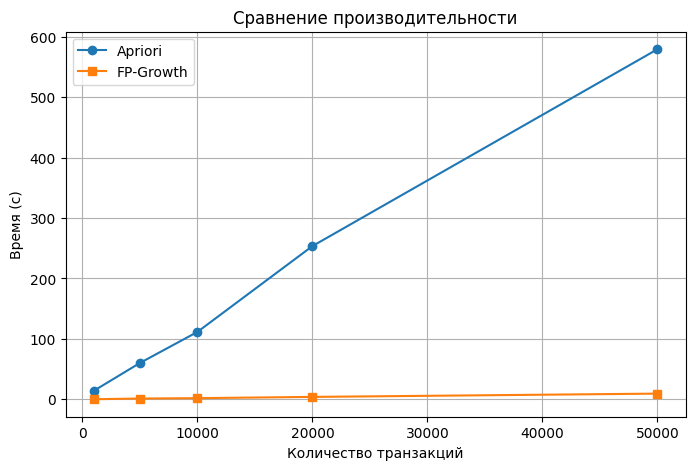

In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic(num_trans, num_items=100, avg_len=10):
    items_pool = [f'item_{i}' for i in range(num_items)]
    freqs = np.random.power(1.5, num_items)
    freqs /= freqs.sum()
    transactions = []
    for _ in range(num_trans):
        length = max(1, min(int(np.random.poisson(avg_len)), num_items))
        chosen = np.random.choice(items_pool, size=length, replace=False, p=freqs)
        transactions.append(chosen.tolist())
    return transactions

trans_counts = [1000, 5000, 10000, 20000, 50000]
min_sup = 0.01
ap_times, fp_times = [], []

for N in trans_counts:
    print(f"Генерация {N} транзакций...")
    synth = generate_synthetic(N)
    synth_sets = [set(t) for t in synth]

    t0 = time.time()
    _ = apriori(synth_sets, min_sup)
    ap_times.append(time.time() - t0)

    t0 = time.time()
    _ = fpgrowth(synth, min_sup)
    fp_times.append(time.time() - t0)

    print(f"  Apriori: {ap_times[-1]:.2f} с, FP‑Growth: {fp_times[-1]:.2f} с")

plt.figure(figsize=(8,5))
plt.plot(trans_counts, ap_times, marker='o', label='Apriori')
plt.plot(trans_counts, fp_times, marker='s', label='FP‑Growth')
plt.xlabel('Количество транзакций')
plt.ylabel('Время (с)')
plt.title('Сравнение производительности')
plt.legend()
plt.grid(True)
plt.show()

Задание №6. Визуализация ассоциативных правил

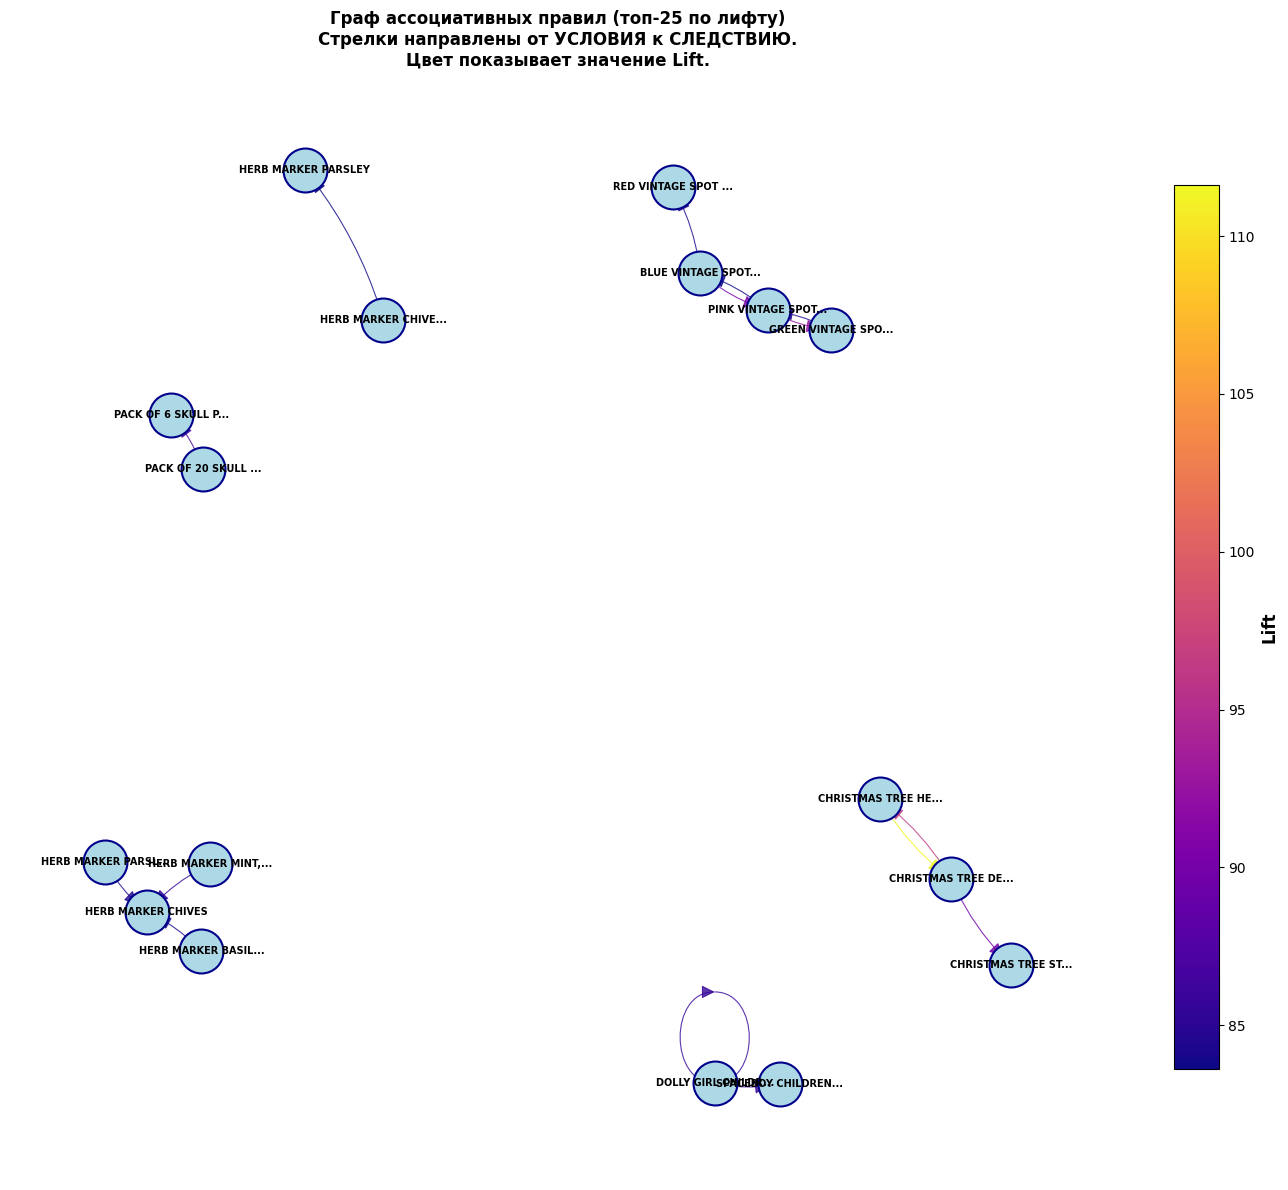

Граф: узлы – товары или группы товаров (антецедент и консеквент).
Стрелка всегда идёт от условия (слева) к следствию (справа).
Цвет от тёмного (низкий Lift) до жёлтого (высокий Lift).


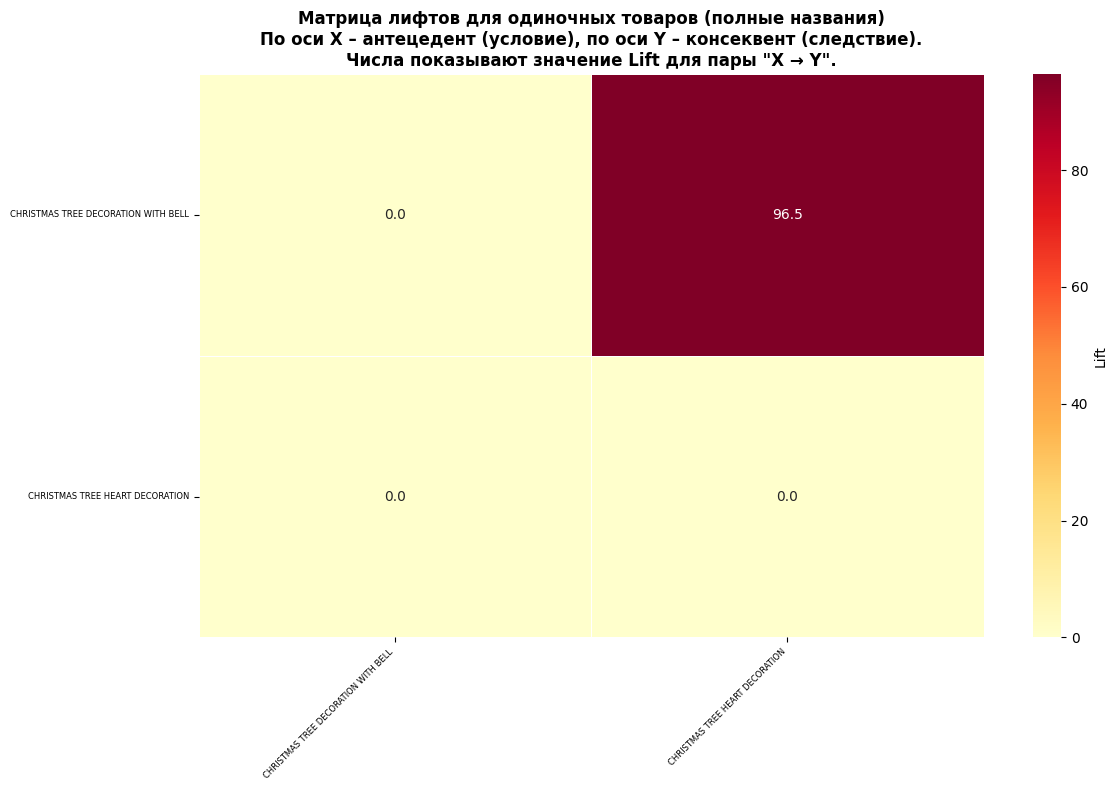

Heatmap: теперь видны полные названия товаров, яркие ячейки – сильная связь.


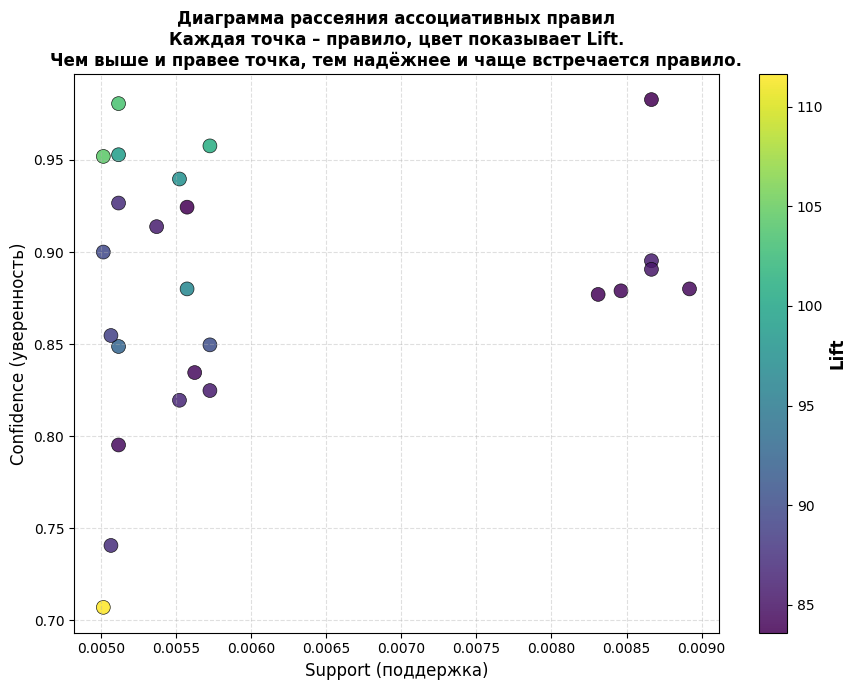

Scatter: показывает компромисс между поддержкой и уверенностью.
Наиболее «интересные» правила – с высоким лифтом (жёлто-зелёные точки).


In [ ]:

import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


def short_name(name, max_len=20):
    """Сокращает название до max_len символов, добавляя '...', если длиннее."""
    if len(name) <= max_len:
        return name
    return name[:max_len-3] + '...'


vis_rules = []
for r in results:
    if r['support'] == 0.005 and r['confidence'] == 0.7:
        vis_rules = sorted(r['rules'], key=lambda x: x[4], reverse=True)[:25]
        break
if not vis_rules:
    for r in results:
        if r['support'] == 0.005 and r['confidence'] == 0.5:
            vis_rules = sorted(r['rules'], key=lambda x: x[4], reverse=True)[:25]
            break

if not vis_rules:
    print("Не удалось найти правила для визуализации! Проверьте Блок 4.")
else:

    #  Направленный граф ассоциативных правил

    G = nx.DiGraph()
    for X, Y, supp, conf, lift, conv, lev in vis_rules:
        ant = short_name(', '.join(X))
        cons = short_name(', '.join(Y))
        G.add_node(ant)
        G.add_node(cons)
        G.add_edge(ant, cons, weight=lift)

    plt.figure(figsize=(14, 12))


    pos = nx.spring_layout(G, k=1.2, seed=42)


    edges = G.edges(data=True)
    lifts = [d['weight'] for _, _, d in edges]


    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1000,
                           edgecolors='darkblue', linewidths=1.5)


    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')


    draw_edges = nx.draw_networkx_edges(
        G, pos,
        width=0.8,                       #
        edge_color=lifts,
        edge_cmap=plt.cm.plasma,
        alpha=0.8,
        arrows=True,
        arrowsize=20,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.1',
    )


    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=min(lifts), vmax=max(lifts))
    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
    cbar.set_label('Lift', fontsize=12, fontweight='bold')

    plt.title('Граф ассоциативных правил (топ-25 по лифту)\n'
              'Стрелки направлены от УСЛОВИЯ к СЛЕДСТВИЮ.\n'
              'Цвет показывает значение Lift.',
              fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("Граф: узлы – товары или группы товаров (антецедент и консеквент).\n"
          "Стрелка всегда идёт от условия (слева) к следствию (справа).\n"
          "Цвет от тёмного (низкий Lift) до жёлтого (высокий Lift).")


    #  Матрица лифтов (heatmap) для пар одиночных товаров

    pair_lift = defaultdict(float)
    for X, Y, supp, conf, lift, conv, lev in vis_rules:
        if len(X) == 1 and len(Y) == 1:
            pair_lift[(X[0], Y[0])] = max(pair_lift[(X[0], Y[0])], lift)

    if pair_lift:

        items_full = sorted(set(a for a, b in pair_lift) | set(b for a, b in pair_lift))
        n = len(items_full)
        mat = np.zeros((n, n))
        idx = {item: i for i, item in enumerate(items_full)}
        for (a, b), l in pair_lift.items():
            mat[idx[a], idx[b]] = l


        plt.figure(figsize=(max(12, n*0.9), max(8, n*0.7)))
        sns.heatmap(mat,
                    xticklabels=items_full,
                    yticklabels=items_full,
                    cmap='YlOrRd',
                    annot=True, fmt='.1f',
                    linewidths=0.5,
                    cbar_kws={'label': 'Lift'})
        plt.title('Матрица лифтов для одиночных товаров (полные названия)\n'
                  'По оси X – антецедент (условие), по оси Y – консеквент (следствие).\n'
                  'Числа показывают значение Lift для пары "X → Y".',
                  fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=6)
        plt.yticks(rotation=0, fontsize=6)
        plt.tight_layout()
        plt.show()
        print("Heatmap:  яркие ячейки – сильная связь.")
    else:
        print("Нет правил с одиночным антецедентом и консеквентом – heatmap не строится.")


     # Диаграмма рассеяния support–confidence с цветом по lift

    supps = [r[2] for r in vis_rules]
    confs = [r[3] for r in vis_rules]
    lifts = [r[4] for r in vis_rules]

    plt.figure(figsize=(9, 7))
    sc = plt.scatter(supps, confs, c=lifts, cmap='viridis', s=100,
                     edgecolor='k', linewidth=0.5, alpha=0.85)
    cbar = plt.colorbar(sc)
    cbar.set_label('Lift', fontsize=12, fontweight='bold')
    plt.xlabel('Support (поддержка)', fontsize=12)
    plt.ylabel('Confidence (уверенность)', fontsize=12)
    plt.title('Диаграмма рассеяния ассоциативных правил\n'
              'Каждая точка – правило, цвет показывает Lift.\n'
              'Чем выше и правее точка, тем надёжнее и чаще встречается правило.',
              fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    print("Scatter: показывает компромисс между поддержкой и уверенностью.\n"
          "Наиболее «интересные» правила – с высоким лифтом (жёлто-зелёные точки).")

Задание 7. Интерпретация результатов

In [ ]:

print("""
===== ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ =====
1. Обнаруженные правила в основном связывают товары для дома и праздничные аксессуары,
   что характерно для магазина подарков. Высокий лифт у пар типа
   "KNITTED UNION FLAG HOT WATER BOTTLE" → "RED WOOLLY HOTTIE WHITE HEART."
   говорит о том, что их часто покупают вместе – отличные кандидаты для кросс-продаж.

2. Правила с очень низкой поддержкой (редкие товары) могут быть статистически
   незначимыми и не подходят для массового использования.

3. Некоторые правила могут быть тривиальными (например, товары одной серии),
   они не дают нового знания о поведении покупателей.

4. При уменьшении min_support количество правил резко возрастает, что усложняет
   интерпретацию; для практического внедрения стоит выбирать умеренные пороги.

5. FP‑Growth показал значительно лучшую производительность на больших данных,
   что подтверждает его преимущество перед Apriori для реальных задач.
""")